# CS541 Challenge — Student Starter Baseline


This notebook provides a simple baseline students can extend.

**Local Windows + NVIDIA GPU:** use a Python 3.10+ venv, open this notebook from Cursor/VS Code or Jupyter, run cells top to bottom. Install [NVIDIA drivers](https://www.nvidia.com/Download/index.aspx); the second code cell pulls CUDA 12.4 PyTorch wheels when needed. If you see CPU-only after pip, restart the kernel.

What this starter includes:
- CIFAR-100 train/val/test pipeline
- **Default model: `SmallResNet`** (BN + residual blocks + GAP) and training: augmentations (incl. light grayscale), AdamW, cosine LR, label smoothing, checkpoint + early stopping (see `cs541_cnn_study_build_guide.md`)
- **`MyCNN`** / **`SimpleCNN`** kept if you want to compare
- Training + validation loop
- OOD inference (optional **horizontal-flip TTA** on logits) and submission file generation

What students should improve next:
- Stronger architectures (e.g. shallow ResNet), TTA, Mixup/CutMix, ensembling
- Tune `CFG` / patience if you have extra GPU budget

### Pretrained Fine-Tuning Option (Part 2)
- Set `EXPERIMENT_NAME = "PT"` in the experiment cell.
- This uses an ImageNet-pretrained `resnet18` (`model_name="resnet18_imagenet_ft"`) and fine-tunes it for CIFAR-100.
- The PT setup runs staged training (`freeze_backbone_epochs` then full-model fine-tuning) and writes checkpoints exactly like other experiments.
- Compared with `small_resnet`, this usually gives stronger transfer performance but may need more GPU memory/time per epoch.


In [1]:
# Runtime configuration
FAST_DEV_RUN = False  # True = quick smoke test
SEED = 42

import os
import platform

IN_COLAB = False
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

IS_WINDOWS = platform.system() == "Windows"

# Colab: /content. Local (e.g. Windows + RTX): project folder ./temp_student (data + checkpoints live here).
WORK_ROOT = "/content" if IN_COLAB else os.path.abspath("./temp_student")
os.makedirs(WORK_ROOT, exist_ok=True)

DATA_ROOT = os.path.join(WORK_ROOT, "data")
OOD_DIR = os.path.join(WORK_ROOT, "ood-test-CS541")
SUBMISSION_PATH = os.path.join(WORK_ROOT, "submission_ood.csv")

print("IN_COLAB:", IN_COLAB, "| IS_WINDOWS:", IS_WINDOWS)
print("WORK_ROOT:", WORK_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("OOD_DIR:", OOD_DIR)
print("SUBMISSION_PATH:", SUBMISSION_PATH)


IN_COLAB: False | IS_WINDOWS: True
WORK_ROOT: c:\Users\15618\Desktop\541\541-challange\temp_student
DATA_ROOT: c:\Users\15618\Desktop\541\541-challange\temp_student\data
OOD_DIR: c:\Users\15618\Desktop\541\541-challange\temp_student\ood-test-CS541
SUBMISSION_PATH: c:\Users\15618\Desktop\541\541-challange\temp_student\submission_ood.csv


In [2]:
# Install required packages (safe to re-run)
import importlib.util
import platform
import subprocess
import sys

required = ["torch", "torchvision", "tqdm", "numpy", "pandas", "matplotlib", "huggingface_hub"]
missing = [p for p in required if importlib.util.find_spec(p) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", *missing])

# On Windows, the default PyPI wheel for torch is often CPU-only; use the official CUDA build for local NVIDIA GPUs (e.g. RTX 4060).
if platform.system() == "Windows":
    import torch

    if torch.version.cuda is None:
        print("Installing CUDA-enabled PyTorch (cu124). Restart the kernel once if pip upgraded an already-imported torch.")
        subprocess.check_call(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                "-U",
                "torch",
                "torchvision",
                "--index-url",
                "https://download.pytorch.org/whl/cu124",
            ]
        )

print("Environment ready")


Environment ready


In [3]:
import os
import platform
import random
from typing import Dict, Optional, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
from tqdm.auto import tqdm


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def get_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


def accuracy_top1(logits: torch.Tensor, targets: torch.Tensor) -> float:
    return (logits.argmax(dim=1) == targets).float().mean().item()


# Must match OOD preprocessing in this notebook (do not change values).
CIFAR_MEAN = (0.5071, 0.4867, 0.4408)
CIFAR_STD = (0.2675, 0.2565, 0.2761)


def make_loaders(batch_size: int, num_workers: int) -> Tuple[DataLoader, DataLoader, DataLoader]:
    mean = CIFAR_MEAN  ### DO NOT CHANGE THIS
    std = CIFAR_STD  ### DO NOT CHANGE THIS
    train_tfms = transforms.Compose(
        [
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.05),
            transforms.RandomGrayscale(p=0.1),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
            transforms.RandomErasing(p=0.25, scale=(0.02, 0.2), ratio=(0.3, 3.3), value="random"),
        ]
    )
    eval_tfms = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean, std)])

    train_full = datasets.CIFAR100(root=DATA_ROOT, train=True, download=True, transform=train_tfms)
    test_ds = datasets.CIFAR100(root=DATA_ROOT, train=False, download=True, transform=eval_tfms)

    n = len(train_full)
    n_train = int(0.8 * n)
    n_val = n - n_train
    g = torch.Generator().manual_seed(SEED)
    train_ds, val_ds = torch.utils.data.random_split(train_full, [n_train, n_val], generator=g)

    if FAST_DEV_RUN:
        train_ds = torch.utils.data.Subset(train_ds, range(min(2048, len(train_ds))))
        val_ds = torch.utils.data.Subset(val_ds, range(min(1024, len(val_ds))))
        test_ds = torch.utils.data.Subset(test_ds, range(min(1024, len(test_ds))))

    # Colab + Windows/Jupyter: multiple workers often hurts or breaks DataLoader workers.
    if IN_COLAB or platform.system() == "Windows":
        num_workers = 0

    pin = torch.cuda.is_available()
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=pin)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin)
    return train_loader, val_loader, test_loader


class SimpleCNN(nn.Module):
    """A lightweight baseline CNN for CIFAR-100."""
    def __init__(self, num_classes: int = 100):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(x))


def conv_bn_relu(in_c, out_c):
    return nn.Sequential(
        nn.Conv2d(in_c, out_c, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(out_c),
        nn.ReLU(inplace=True),
    )


class MyCNN(nn.Module):
    def __init__(self, num_classes: int = 100):
        super().__init__()
        self.features = nn.Sequential(
            conv_bn_relu(3, 64),
            conv_bn_relu(64, 64),
            nn.MaxPool2d(2),  # 32 -> 16

            conv_bn_relu(64, 128),
            conv_bn_relu(128, 128),
            nn.MaxPool2d(2),  # 16 -> 8

            conv_bn_relu(128, 256),
            conv_bn_relu(256, 256),
            nn.MaxPool2d(2),  # 8 -> 4
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.head(self.features(x))


class BasicBlock(nn.Module):
    """Two 3x3 convs + BN + residual shortcut (CIFAR-style)."""

    def __init__(self, in_planes: int, planes: int, stride: int = 1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, 3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes),
            )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        return F.relu(out)


class SmallResNet(nn.Module):
    """Shallow ResNet for 32x32: stem + 3 stages (32/16/8) + GAP."""

    def __init__(self, num_classes: int = 100, width: int = 64):
        super().__init__()
        self.in_planes = width
        self.conv1 = nn.Conv2d(3, width, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(width)
        self.layer1 = self._make_layer(width, 2, stride=1)
        self.layer2 = self._make_layer(width * 2, 2, stride=2)
        self.layer3 = self._make_layer(width * 4, 2, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(width * 4, num_classes)

    def _make_layer(self, planes: int, num_blocks: int, stride: int) -> nn.Sequential:
        blocks = [BasicBlock(self.in_planes, planes, stride)]
        self.in_planes = planes
        for _ in range(1, num_blocks):
            blocks.append(BasicBlock(self.in_planes, planes, 1))
        return nn.Sequential(*blocks)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avgpool(out).flatten(1)
        out = self.dropout(out)
        return self.fc(out)


class ResNetCIFAR(nn.Module):
    """Stronger CIFAR backbone: 4 residual stages (ResNet-18/34 style)."""

    def __init__(self, num_classes: int = 100, base_width: int = 64, layers: tuple = (2, 2, 2, 2), dropout: float = 0.2):
        super().__init__()
        self.in_planes = base_width
        self.conv1 = nn.Conv2d(3, base_width, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(base_width)
        self.layer1 = self._make_layer(base_width, layers[0], stride=1)
        self.layer2 = self._make_layer(base_width * 2, layers[1], stride=2)
        self.layer3 = self._make_layer(base_width * 4, layers[2], stride=2)
        self.layer4 = self._make_layer(base_width * 8, layers[3], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(base_width * 8, num_classes)

    def _make_layer(self, planes: int, num_blocks: int, stride: int) -> nn.Sequential:
        blocks = [BasicBlock(self.in_planes, planes, stride)]
        self.in_planes = planes
        for _ in range(1, num_blocks):
            blocks.append(BasicBlock(self.in_planes, planes, 1))
        return nn.Sequential(*blocks)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out).flatten(1)
        out = self.dropout(out)
        return self.fc(out)


def _build_imagenet_resnet(model_name: str, num_classes: int = 100, cifar_stem: bool = True) -> nn.Module:
    if model_name == "resnet18_imagenet_ft":
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    elif model_name == "resnet50_imagenet_ft":
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    else:
        raise ValueError(f"Unknown pretrained model_name: {model_name}")

    if cifar_stem:
        # CIFAR images are 32x32; a smaller stem avoids over-downsampling at input.
        model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        model.maxpool = nn.Identity()

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model


def build_model(cfg: Dict) -> nn.Module:
    name = cfg.get("model_name", "small_resnet")
    width = int(cfg.get("model_width", 64))
    dropout = float(cfg.get("model_dropout", 0.2))
    if name == "small_resnet":
        return SmallResNet(num_classes=100, width=width)
    if name == "resnet18_cifar":
        return ResNetCIFAR(num_classes=100, base_width=width, layers=(2, 2, 2, 2), dropout=dropout)
    if name == "resnet34_cifar":
        return ResNetCIFAR(num_classes=100, base_width=width, layers=(3, 4, 6, 3), dropout=dropout)
    if name in {"resnet18_imagenet_ft", "resnet50_imagenet_ft"}:
        return _build_imagenet_resnet(
            model_name=name,
            num_classes=100,
            cifar_stem=bool(cfg.get("cifar_stem", True)),
        )
    raise ValueError(f"Unknown model_name: {name}")


def mixup_batch(x: torch.Tensor, y: torch.Tensor, alpha: float):
    if alpha <= 0:
        return x, y, y, 1.0
    lam = float(np.random.beta(alpha, alpha))
    index = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1.0 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam


def cutmix_batch(x: torch.Tensor, y: torch.Tensor, alpha: float) -> tuple:
    """CutMix; lam is area fraction of first image (matches standard CutMix loss weighting)."""
    if alpha <= 0:
        return x, y, y, 1.0
    lam = float(np.random.beta(alpha, alpha))
    index = torch.randperm(x.size(0), device=x.device)
    _, _, h, w = x.shape
    cut_r = np.sqrt(max(1e-8, 1.0 - lam))
    cut_h = int(h * cut_r)
    cut_w = int(w * cut_r)
    cy = int(np.random.randint(h))
    cx = int(np.random.randint(w))
    y1 = int(np.clip(cy - cut_h // 2, 0, h))
    y2 = int(np.clip(cy + cut_h // 2, 0, h))
    x1 = int(np.clip(cx - cut_w // 2, 0, w))
    x2 = int(np.clip(cx + cut_w // 2, 0, w))
    x_m = x.clone()
    x_m[:, :, y1:y2, x1:x2] = x[index, :, y1:y2, x1:x2]
    lam_adj = 1.0 - ((y2 - y1) * (x2 - x1) / (h * w))
    y_a, y_b = y, y[index]
    return x_m, y_a, y_b, float(lam_adj)


def fit(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
    epochs: int,
    scheduler=None,
    checkpoint_path: Optional[str] = None,
    early_stopping_patience: Optional[int] = None,
    mixup_alpha: float = 0.0,
    cutmix_alpha: float = 0.0,
) -> Dict[str, list]:
    """Train with optional cosine scheduler, checkpoint, early stopping, Mixup and/or CutMix."""
    history = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}
    best_val_acc = -1.0
    best_state = None
    epochs_no_gain = 0

    for epoch in range(1, epochs + 1):
        model.train()
        tr_correct, tr_total = 0, 0
        tr_loss_sum, tr_n = 0.0, 0
        for x, y in tqdm(train_loader, desc=f"train {epoch}/{epochs}", leave=False):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad(set_to_none=True)
            if cutmix_alpha > 0 and mixup_alpha > 0:
                do_cutmix = torch.rand(1, device=x.device).item() < 0.5
            else:
                do_cutmix = cutmix_alpha > 0

            if do_cutmix:
                x, y_a, y_b, lam = cutmix_batch(x, y, cutmix_alpha)
                logits = model(x)
                loss = lam * criterion(logits, y_a) + (1.0 - lam) * criterion(logits, y_b)
                tr_correct += (logits.argmax(1) == y_a).sum().item()
            elif mixup_alpha > 0:
                x, y_a, y_b, lam = mixup_batch(x, y, mixup_alpha)
                logits = model(x)
                loss = lam * criterion(logits, y_a) + (1.0 - lam) * criterion(logits, y_b)
                tr_correct += (logits.argmax(1) == y_a).sum().item()
            else:
                logits = model(x)
                loss = criterion(logits, y)
                tr_correct += (logits.argmax(1) == y).sum().item()
            loss.backward()
            optimizer.step()
            bs = y.size(0)
            tr_loss_sum += loss.item() * bs
            tr_n += bs
            tr_total += y.numel()

        model.eval()
        va_correct, va_total = 0, 0
        va_loss_sum = 0.0
        with torch.no_grad():
            for x, y in tqdm(val_loader, desc=f"val {epoch}/{epochs}", leave=False):
                x, y = x.to(device), y.to(device)
                logits = model(x)
                v_loss = criterion(logits, y)
                va_loss_sum += v_loss.item() * y.size(0)
                va_correct += (logits.argmax(1) == y).sum().item()
                va_total += y.numel()

        tr_acc = tr_correct / max(tr_total, 1)
        va_acc = va_correct / max(va_total, 1)
        tr_loss_mean = tr_loss_sum / max(tr_n, 1)
        va_loss_mean = va_loss_sum / max(va_total, 1)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)
        history["train_loss"].append(tr_loss_mean)
        history["val_loss"].append(va_loss_mean)
        lr_cur = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch {epoch:03d}/{epochs} | train {tr_acc:.4f} | val {va_acc:.4f} | "
            f"tr_loss {tr_loss_mean:.4f} | val_loss {va_loss_mean:.4f} | lr {lr_cur:.2e}"
        )

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_gain = 0
            if checkpoint_path:
                torch.save(
                    {"model": model.state_dict(), "val_acc": float(va_acc), "epoch": epoch},
                    checkpoint_path,
                )
        else:
            if early_stopping_patience is not None:
                epochs_no_gain += 1
                if epochs_no_gain >= early_stopping_patience:
                    print(
                        f"Early stopping at epoch {epoch} (no val improvement for {early_stopping_patience} epochs)"
                    )
                    break

        if scheduler is not None:
            scheduler.step()

    if best_state is not None:
        model.load_state_dict(best_state)
    print("Best val acc:", best_val_acc)
    return history


@torch.no_grad()
def eval_clean(model: nn.Module, loader: DataLoader, device: torch.device) -> float:
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.numel()
    return 100.0 * correct / total


set_seed(SEED)
device = get_device()
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("PyTorch CUDA:", torch.version.cuda)
else:
    print("No CUDA in this session — install NVIDIA drivers + CUDA PyTorch, then restart the kernel.")


Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
PyTorch CUDA: 12.4


In [17]:
# Quick experiment presets for leaderboard iteration.
# A = baseline, B = Mixup, C = wider net, D = long run (80 ep) — cosine T_max matches epochs.
# Change only EXPERIMENT_NAME to switch setups.

import platform

EXPERIMENT_NAME = "PT"  # choose from: "A", "B", "C", "D", "E (best model so far)", "F", "PT", "PT-2"

# Match make_loaders: 0 workers on Colab and Windows (stable in Jupyter).
_NUM_DATALOADER_WORKERS = 0 if (IN_COLAB or platform.system() == "Windows") else 2

EXPERIMENTS = {
    "A": {
        "batch_size": 128,
        "num_workers": _NUM_DATALOADER_WORKERS,
        "epochs": 30 if not FAST_DEV_RUN else 2,
        "lr": 5e-4,
        "weight_decay": 5e-4,
        "label_smoothing": 0.05,
        "early_stopping_patience": 10 if not FAST_DEV_RUN else None,
        "mixup_alpha": 0.0,
        "cutmix_alpha": 0.0,
        "model_name": "small_resnet",
        "model_width": 64,
        "model_dropout": 0.2,
    },
    "B": {
        "batch_size": 128,
        "num_workers": _NUM_DATALOADER_WORKERS,
        "epochs": 30 if not FAST_DEV_RUN else 2,
        "lr": 5e-4,
        "weight_decay": 5e-4,
        "label_smoothing": 0.03,
        "early_stopping_patience": 10 if not FAST_DEV_RUN else None,
        "mixup_alpha": 0.2,
        "cutmix_alpha": 0.0,
        "model_name": "small_resnet",
        "model_width": 64,
        "model_dropout": 0.2,
    },
    "C": {
        "batch_size": 96 if not FAST_DEV_RUN else 32,
        "num_workers": _NUM_DATALOADER_WORKERS,
        "epochs": 40 if not FAST_DEV_RUN else 2,
        "lr": 5e-4,
        "weight_decay": 5e-4,
        "label_smoothing": 0.05,
        "early_stopping_patience": 10 if not FAST_DEV_RUN else None,
        "mixup_alpha": 0.0,
        "cutmix_alpha": 0.0,
        "model_name": "small_resnet",
        "model_width": 80,
        "model_dropout": 0.2,
    },
    "D": {
        # Long training: T_max=epochs (cosine spans full run). Slightly lower lr + higher patience
        # reduces instability over many passes; no Mixup so gains are mostly from optimization depth.
        "batch_size": 128,
        "num_workers": _NUM_DATALOADER_WORKERS,
        "epochs": 60 if not FAST_DEV_RUN else 2,
        "lr": 3e-4,
        "weight_decay": 5e-4,
        "label_smoothing": 0.05,
        "early_stopping_patience": 15 if not FAST_DEV_RUN else None,
        "mixup_alpha": 0.0,
        "cutmix_alpha": 0.0,
        "model_name": "small_resnet",
        "model_width": 64,
        "model_dropout": 0.2,
    },
    "E": {
        # Stronger backbone + robust regularization for OOD leaderboard.
        "batch_size": 128,
        "num_workers": _NUM_DATALOADER_WORKERS,
        "epochs": 120 if not FAST_DEV_RUN else 2,
        # "lr": 3e-4,
        "lr": 3.5e-4,
        "weight_decay": 1e-3,
        "label_smoothing": 0.05,
        "early_stopping_patience": 15 if not FAST_DEV_RUN else None,
        "mixup_alpha": 0.2,
        "cutmix_alpha": 0.3,
        "model_name": "resnet34_cifar",
        # "model_width": 64,
        "model_width": 80,
        "model_dropout": 0.25,
    },
    "F": {
        # Long training: T_max=epochs (cosine spans full run). Slightly lower lr + higher patience
        # reduces instability over many passes; no Mixup so gains are mostly from optimization depth.
        "batch_size": 128,
        "num_workers": _NUM_DATALOADER_WORKERS,
        "epochs": 70 if not FAST_DEV_RUN else 2,
        "lr": 3e-4,
        "weight_decay": 2e-3,
        "label_smoothing": 0.1,
        "early_stopping_patience": 15 if not FAST_DEV_RUN else None,
        "mixup_alpha": 0.1,
        "cutmix_alpha": 1.0,
        "model_name": "small_resnet",
        "model_width": 80,
        "model_dropout": 0.2,
    },
    "PT": {
    "batch_size": 128,
    "num_workers": _NUM_DATALOADER_WORKERS,
    "epochs": 95 if not FAST_DEV_RUN else 2,
    "lr": 1.5e-4,
    "weight_decay": 1e-4,
    "label_smoothing": 0.05,
    "early_stopping_patience": 12 if not FAST_DEV_RUN else None,
    "mixup_alpha": 0.2,
    "cutmix_alpha": 0.3,
    "model_name": "resnet18_imagenet_ft",
    "pretrained": True,
    "cifar_stem": True,
    "freeze_backbone_epochs": 2 if not FAST_DEV_RUN else 1,
},
    "PT-2": {
    "batch_size": 128,
    "num_workers": _NUM_DATALOADER_WORKERS,
    "epochs": 70 if not FAST_DEV_RUN else 2,
    "lr": 1.5e-4,
    "weight_decay": 1e-4,
    "label_smoothing": 0.05,
    "early_stopping_patience": 10 if not FAST_DEV_RUN else None,
    "mixup_alpha": 0.0,
    "cutmix_alpha": 0.0,
    "model_name": "resnet18_imagenet_ft",
    "pretrained": True,
    "cifar_stem": True,
    "freeze_backbone_epochs": 2 if not FAST_DEV_RUN else 1,
    },
}

CFG = EXPERIMENTS[EXPERIMENT_NAME].copy()
CHECKPOINT_PATH = os.path.join(WORK_ROOT, f"best_model_{EXPERIMENT_NAME.lower()}.pt")

print("Running experiment", EXPERIMENT_NAME)
print(CFG)
print("Checkpoint:", CHECKPOINT_PATH)
print(
    "Model:",
    CFG["model_name"],
    "| width:",
    CFG.get("model_width", "n/a"),
    "| dropout:",
    CFG.get("model_dropout", "n/a"),
    "| freeze_backbone_epochs:",
    CFG.get("freeze_backbone_epochs", 0),
)

train_loader, val_loader, test_loader = make_loaders(CFG["batch_size"], CFG["num_workers"])

def _set_backbone_trainable(model: nn.Module, trainable: bool) -> None:
    for name, param in model.named_parameters():
        if name.startswith("fc."):
            param.requires_grad = True
        else:
            param.requires_grad = trainable


def _merge_histories(*parts: Dict[str, list]) -> Dict[str, list]:
    merged = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}
    for part in parts:
        for k in merged:
            merged[k].extend(part.get(k, []))
    return merged


set_seed(SEED)
model = build_model(CFG).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=CFG["label_smoothing"])

freeze_epochs = int(CFG.get("freeze_backbone_epochs", 0))
freeze_epochs = max(0, min(freeze_epochs, int(CFG["epochs"])))

if freeze_epochs > 0 and hasattr(model, "fc"):
    print(f"Stage 1: train head only for {freeze_epochs} epoch(s)")
    _set_backbone_trainable(model, trainable=False)
    opt_head = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=CFG["lr"],
        weight_decay=CFG["weight_decay"],
    )
    sch_head = torch.optim.lr_scheduler.CosineAnnealingLR(opt_head, T_max=freeze_epochs)
    hist_head = fit(
        model,
        train_loader,
        val_loader,
        opt_head,
        criterion,
        device,
        freeze_epochs,
        scheduler=sch_head,
        checkpoint_path=CHECKPOINT_PATH,
        early_stopping_patience=None,
        mixup_alpha=CFG["mixup_alpha"],
        cutmix_alpha=CFG["cutmix_alpha"],
    )

    remaining_epochs = int(CFG["epochs"]) - freeze_epochs
    if remaining_epochs > 0:
        print(f"Stage 2: unfreeze full model for {remaining_epochs} epoch(s)")
        _set_backbone_trainable(model, trainable=True)
        opt_full = torch.optim.AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])
        sch_full = torch.optim.lr_scheduler.CosineAnnealingLR(opt_full, T_max=remaining_epochs)
        hist_full = fit(
            model,
            train_loader,
            val_loader,
            opt_full,
            criterion,
            device,
            remaining_epochs,
            scheduler=sch_full,
            checkpoint_path=CHECKPOINT_PATH,
            early_stopping_patience=CFG["early_stopping_patience"],
            mixup_alpha=CFG["mixup_alpha"],
            cutmix_alpha=CFG["cutmix_alpha"],
        )
        history = _merge_histories(hist_head, hist_full)
    else:
        history = hist_head
else:
    optimizer = torch.optim.AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG["epochs"])
    history = fit(
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        device,
        CFG["epochs"],
        scheduler=scheduler,
        checkpoint_path=CHECKPOINT_PATH,
        early_stopping_patience=CFG["early_stopping_patience"],
        mixup_alpha=CFG["mixup_alpha"],
        cutmix_alpha=CFG["cutmix_alpha"],
    )

test_acc = eval_clean(model, test_loader, device)
print(f"Clean CIFAR-100 test accuracy: {test_acc:.2f}%")
print("Saved best checkpoint:", CHECKPOINT_PATH)
print("For OOD, make sure the OOD cell loads this same checkpoint path.")

Running experiment PT
{'batch_size': 128, 'num_workers': 0, 'epochs': 95, 'lr': 0.00015, 'weight_decay': 0.0001, 'label_smoothing': 0.05, 'early_stopping_patience': 12, 'mixup_alpha': 0.2, 'cutmix_alpha': 0.3, 'model_name': 'resnet18_imagenet_ft', 'pretrained': True, 'cifar_stem': True, 'freeze_backbone_epochs': 2}
Checkpoint: c:\Users\15618\Desktop\541\541-challange\temp_student\best_model_pt.pt
Model: resnet18_imagenet_ft | width: n/a | dropout: n/a | freeze_backbone_epochs: 2
Stage 1: train head only for 2 epoch(s)


train 1/2:   0%|          | 0/313 [00:00<?, ?it/s]

val 1/2:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 001/2 | train 0.0184 | val 0.0495 | tr_loss 4.6332 | val_loss 4.4122 | lr 1.50e-04


train 2/2:   0%|          | 0/313 [00:00<?, ?it/s]

...

val 92/93:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 092/93 | train 0.5988 | val 0.7679 | tr_loss 1.4527 | val_loss 1.2691 | lr 1.71e-07


train 93/93:   0%|          | 0/313 [00:00<?, ?it/s]

val 93/93:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 093/93 | train 0.6117 | val 0.7714 | tr_loss 1.4214 | val_loss 1.2572 | lr 4.28e-08
Best val acc: 0.7776
Clean CIFAR-100 test accuracy: 79.66%
Saved best checkpoint: c:\Users\15618\Desktop\541\541-challange\temp_student\best_model_pt.pt
For OOD, make sure the OOD cell loads this same checkpoint path.


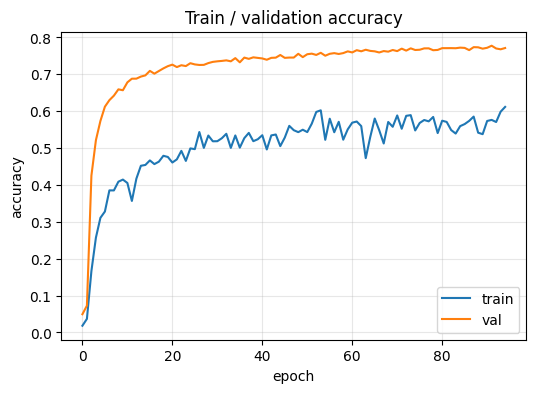

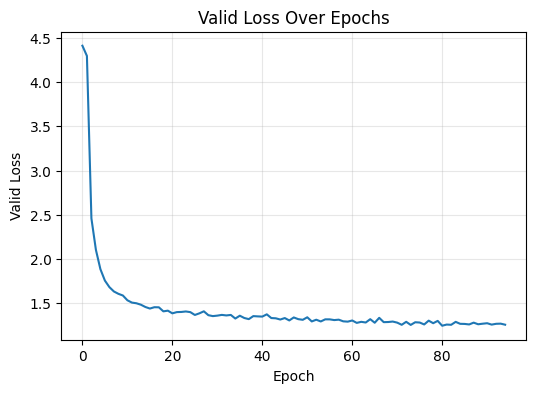

In [18]:
# Optional quick plot of train/val accuracy and validation loss
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(history["train_acc"], label="train")
plt.plot(history["val_acc"], label="val")
plt.title("Train / validation accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history["val_loss"], color="C0")
plt.title("Valid Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Valid Loss")
plt.grid(True, alpha=0.3)
plt.show()


## OOD Submission Generation

This section creates `submission_ood.csv` for challenge evaluation.

Submission format:
- `id`: `distortionXX_severity_index`
- `label`: predicted class in `[0, 99]`


In [19]:
### DO NOT CHANGE THE BELOW, REPLACE WITH YOUR MODEL, THE SUBMISSION FILES NEED TO GO THROUGH THE BELOW PREPROCESSING

from huggingface_hub import snapshot_download

def ensure_ood_files(ood_dir: str) -> None:
    os.makedirs(ood_dir, exist_ok=True)
    print("Downloading OOD files from Hugging Face dataset...")
    snapshot_download(
        repo_id="XThomasBU/ood-test-CS541",
        repo_type="dataset",
        local_dir=ood_dir,
        local_dir_use_symlinks=False,
    )
    print("OOD files ready in", ood_dir)


# Average predictions with a horizontal flip (TTA) — helps OOD without changing normalization.
OOD_HFLIP_TTA = True


@torch.no_grad()
def predict_file(
    model: nn.Module,
    npy_path: str,
    severity: int,
    batch_size: int,
    use_hflip_tta: bool = OOD_HFLIP_TTA,
) -> np.ndarray:
    images = np.load(npy_path, mmap_mode="r")
    start = (severity - 1) * 10000
    end = severity * 10000

    mean = (0.5071, 0.4867, 0.4408)
    std = (0.2675, 0.2565, 0.2761)
    normalize = transforms.Normalize(mean, std)

    preds = []
    model.eval()
    for b0 in tqdm(range(start, end, batch_size), desc=f"{os.path.basename(npy_path)} sev{severity}", leave=False):
        b1 = min(b0 + batch_size, end)
        xb_np = np.array(images[b0:b1], copy=True)
        xb = torch.from_numpy(xb_np).permute(0, 3, 1, 2).float().div(255.0)
        xb = normalize(xb).to(device, non_blocking=True)
        logits = model(xb)
        if use_hflip_tta:
            xb_f = torch.flip(xb, dims=(3,))
            logits = 0.5 * (logits + model(xb_f))
        preds.append(logits.argmax(1).cpu().numpy())
    return np.concatenate(preds, axis=0)


# Load best training weights (required if you re-run this cell without re-training)
# Rebuild model from CFG so OOD loading stays consistent with architecture changes.
model = build_model(CFG).to(device)
_ckpt = CHECKPOINT_PATH if "CHECKPOINT_PATH" in globals() else os.path.join(WORK_ROOT, "best_model.pt")
if os.path.isfile(_ckpt):
    state = torch.load(_ckpt, map_location=device)
    model.load_state_dict(state["model"])
    print("Loaded weights for OOD from", _ckpt, "checkpoint val_acc:", state.get("val_acc"))
else:
    print("Warning: no checkpoint at", _ckpt, "-- using model currently in memory (run training cell first).")

ensure_ood_files(OOD_DIR)

distortion_files = sorted([p for p in os.listdir(OOD_DIR) if p.startswith("distortion") and p.endswith(".npy")])
print("Distortion files found:", len(distortion_files))

rows = []
BATCH = 64 if device.type == "cuda" else 32
for fname in distortion_files:
    dname = os.path.splitext(fname)[0]
    path = os.path.join(OOD_DIR, fname)
    for severity in [1, 2, 3, 4, 5]:
        pred = predict_file(model, path, severity, BATCH)
        for i, y in enumerate(pred.tolist()):
            rows.append((f"{dname}_{severity}_{i}", int(y)))
        print(f"{dname}_{severity} done")

submission = pd.DataFrame(rows, columns=["id", "label"])
submission.to_csv(SUBMISSION_PATH, index=False)
print("Wrote", SUBMISSION_PATH, "rows:", len(submission))


Loaded weights for OOD from c:\Users\15618\Desktop\541\541-challange\temp_student\best_model_pt.pt checkpoint val_acc: 0.7776


Fetching 21 files:   0%|          | 0/21 [00:00<?, ?it/s]

OOD files ready in c:\Users\15618\Desktop\541\541-challange\temp_student\ood-test-CS541
Distortion files found: 20


distortion00.npy sev1:   0%|          | 0/157 [00:00<?, ?it/s]

distortion00_1 done


...

distortion_19_3 done


distortion_19.npy sev4:   0%|          | 0/157 [00:00<?, ?it/s]

distortion_19_4 done


distortion_19.npy sev5:   0%|          | 0/157 [00:00<?, ?it/s]

distortion_19_5 done
Wrote c:\Users\15618\Desktop\541\541-challange\temp_student\submission_ood.csv rows: 1000000


In [23]:
# Google Drive is only for Colab workflows; skip on local Windows/macOS/Linux.
if IN_COLAB:
    from google.colab import drive  # type: ignore

    drive.mount("/content/drive")
else:
    print("Skipping Google Drive mount (local run — data/checkpoints use WORK_ROOT from the first cell).")

Mounted at /content/drive
